# Part D2: Iterative SVD for Missing Data

Part D1 showed that the naive zero-fill strategy degrades badly under missing data — zero-filled entries
distort the low-rank structure and collapse the σ3/σ4 gap. Here we replace zero-fill with **Iterative SVD
(alternating completion)**: initialize missing entries to zero (which equals the per-row mean after centering),
then repeatedly compute rank-3 SVD and overwrite only the missing entries with the reconstruction,
keeping observed entries fixed.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import generate_sfm_data
from src.factorization import factorize_tomasi_kanade
from src.utils import reprojection_rmse, procrustes_align

In [37]:
NUM_POINTS = 50
NUM_FRAMES = 10
SEED = 0

settings = {
    "easy": {"point_shape": "full_3d", "sigma": 0, "missing_rate": 0.05},
    "hard": {"point_shape": "near_planar", "sigma": 0.06, "missing_rate": 0.2},
}

for name, cfg in settings.items():
    print(f"{name}: shape={cfg['point_shape']}, σ={cfg['sigma']}, miss={cfg['missing_rate']:.0%}")

easy: shape=full_3d, σ=0, miss=5%
hard: shape=near_planar, σ=0.06, miss=20%


## Algorithm Description

**Iterative SVD (alternating completion):**

1. Center the measurement matrix (subtract per-row `nanmean`)
2. Initialize missing entries to 0.0 (which is the per-row mean after centering)
3. Repeat until convergence:
   - Compute full SVD, form rank-3 reconstruction: $U_3 \Sigma_3 V_3^T$
   - Replace **only** missing entries with reconstructed values; observed entries stay fixed
   - Check convergence: relative change in filled values  $< 10^{-6}$


## Easy Setting: `full_3d`, σ=0, 5% missing

In [38]:
cfg = settings["easy"]
data_easy = generate_sfm_data(
    num_points=NUM_POINTS, num_frames=NUM_FRAMES, seed=SEED, **cfg
)
W_easy = data_easy["measurement_matrix"]

# Zero-fill baseline
m_zf, s_zf, t_zf = factorize_tomasi_kanade(W_easy)
rmse_zf_easy = reprojection_rmse(W_easy, m_zf, s_zf, t_zf)

# Iterative SVD
m_it, s_it, t_it, hist_easy = factorize_tomasi_kanade(W_easy, missing_strat="iterative-svd")
rmse_it_easy = reprojection_rmse(W_easy, m_it, s_it, t_it)

print(f"Easy setting — Zero-fill RMSE: {rmse_zf_easy:.6f}")
print(f"Easy setting — Iterative SVD RMSE: {rmse_it_easy:.6f}")
print(f"Converged in {len(hist_easy)} iterations")

Easy setting — Zero-fill RMSE: 0.041793
Easy setting — Iterative SVD RMSE: 0.014319
Converged in 16 iterations


## Hard Setting: `near_planar`, σ=0.06, 20% missing

In [39]:
cfg = settings["hard"]
data_hard = generate_sfm_data(
    num_points=NUM_POINTS, num_frames=NUM_FRAMES, seed=SEED, **cfg
)
W_hard = data_hard["measurement_matrix"]

# Zero-fill baseline
m_zf, s_zf, t_zf = factorize_tomasi_kanade(W_hard)
rmse_zf_hard = reprojection_rmse(W_hard, m_zf, s_zf, t_zf)

# Iterative SVD
m_it, s_it, t_it, hist_hard = factorize_tomasi_kanade(W_hard, missing_strat="iterative-svd")
rmse_it_hard = reprojection_rmse(W_hard, m_it, s_it, t_it)

print(f"Hard setting — Zero-fill RMSE: {rmse_zf_hard:.6f}")
print(f"Hard setting — Iterative SVD RMSE: {rmse_it_hard:.6f}")
print(f"Converged in {len(hist_hard)} iterations")

Hard setting — Zero-fill RMSE: 0.139614
Hard setting — Iterative SVD RMSE: 0.047983
Converged in 64 iterations


## Convergence Plot

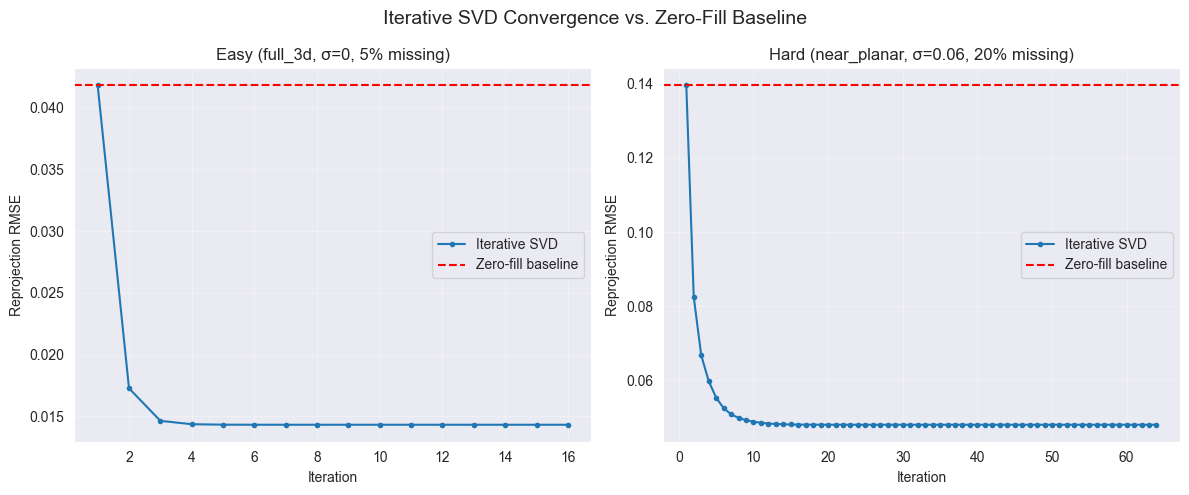

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, hist, rmse_zf, name in [
    (axes[0], hist_easy, rmse_zf_easy, "easy"),
    (axes[1], hist_hard, rmse_zf_hard, "hard"),
]:
    cfg = settings[name]
    label = f"{name.capitalize()} ({cfg['point_shape']}, σ={cfg['sigma']}, {cfg['missing_rate']:.0%} missing)"
    iters = np.arange(1, len(hist) + 1)
    ax.plot(iters, hist, "o-", markersize=3, label="Iterative SVD")
    ax.axhline(rmse_zf, color="red", linestyle="--", linewidth=1.5, label="Zero-fill baseline")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Reprojection RMSE")
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Iterative SVD Convergence vs. Zero-Fill Baseline", fontsize=14)
fig.tight_layout()
plt.show()